# Explainable Artificial Intelligence (XAI)

### Introduction

The previous notebook evaluated Logistic Regression, Decision Tree, Random Forest, XGBoost and Linear Support Vector Machine for multiclass employee-performance prediction. Across held-out evaluation and stratified cross-validation, the models demonstrated broadly comparable and modest predictive performance, with no algorithm consistently outperforming the alternatives.

XGBoost was selected for the explainability stage not because it demonstrated superior predictive accuracy, but because its tree-based gradient-boosting architecture provides a suitable basis for SHAP (SHapley Additive exPlanations) analysis. This enables the contribution of individual predictors to the fitted model's predictions to be examined while retaining the broader finding that predictive performance remains limited.

Predictive performance alone does not explain how a machine-learning model generates its classifications. This notebook therefore applies SHAP to investigate how the fitted XGBoost classifier uses the retained organisational, demographic and behavioural predictors when generating employee-performance predictions.

SHAP provides both global and local explanations of model behaviour. Global explanations summarise the relative contribution of predictors across observations, while local explanations examine how individual feature values contribute to specific model predictions.

Given the modest predictive performance established in Notebook 3, the explainability results are interpreted cautiously. SHAP values explain the behaviour of the fitted XGBoost model; they do not establish causal relationships, independently validate the predictors as determinants of employee performance, or demonstrate that the model is sufficiently accurate for automated organisational decision-making.

The objective of this notebook is therefore to improve transparency regarding model behaviour rather than to provide additional evidence of predictive accuracy.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

from xgboost import XGBClassifier

import joblib

## Load the Refined Encoded Dataset

The full encoded predictor dataset and corresponding target variable produced during preprocessing are loaded for the final explainability analysis.

The predictor dataset contains the refined feature set established in Notebook 2, following the exclusion of variables presenting substantial proxy, temporal-ordering or conceptual-validity concerns. The encoded representation is used because XGBoost requires numerical input and the same feature structure was used during model development.

The full dataset is used here only after predictive model evaluation has been completed. Predictive performance remains assessed using the held-out test results and cross-validation reported in Notebook 3.

In [9]:
X_encoded = pd.read_csv("../Processed_Data/X_encoded.csv")

y = pd.read_csv("../Processed_Data/y.csv").squeeze()

print(X_encoded.shape)
print(y.shape)

(100000, 29)
(100000,)


## Full-Data Refit for Explainability

Predictive performance was evaluated in Notebook 3 using the predefined training and held-out test partitions, with comparative stratified cross-validation conducted using the training data. Those results remain the basis for assessing the predictive capability and generalisation performance of the evaluated models.

Following completion of model evaluation and selection of XGBoost for explainability, the classifier is refitted using the complete leakage-controlled dataset. This refit is undertaken solely to support the final descriptive explainability analysis and allows SHAP values to be calculated using all available observations within the refined dataset.

The full-data refitted model is analytically distinct from the held-out model used to estimate predictive performance. Consequently, no predictive-performance claims are derived from this refit, and the SHAP results produced below should be interpreted as explanations of the behaviour of the full-data refitted XGBoost model rather than as additional evidence of out-of-sample predictive validity.

In [10]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_encoded,
    y - 1
)

print("Model trained successfully.")

Model trained successfully.


## Calculate SHAP Values

SHAP values are calculated using `TreeExplainer`, which is designed for tree-based machine-learning models such as XGBoost.

For each observation, SHAP decomposes the fitted model's output into feature-level contributions relative to the model's expected output. Because `Performance_Score` is modelled as a five-class classification problem, SHAP values are generated across the five target classes.

The resulting SHAP values describe how the fitted XGBoost model uses each encoded predictor when generating its classifications. They should therefore be interpreted as model-specific attribution values rather than estimates of causal effects or independent measures of the substantive importance of employee characteristics.

In [11]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_encoded)

print("SHAP values calculated.")

SHAP values calculated.


## Global Feature Importance

Following calculation of the SHAP values, global feature importance is examined to identify which predictors make the largest contributions to the predictions generated by the full-data refitted XGBoost model.

Traditional feature-importance measures can indicate which variables are used by a model but often provide limited information about their contribution to individual predictions. SHAP provides a theoretically grounded attribution framework in which feature contributions are evaluated relative to the model's expected output.

For this multiclass model, global importance is calculated using the mean absolute SHAP value across observations and target classes. Taking absolute values captures the magnitude of each feature's contribution irrespective of whether that contribution increases or decreases the model output for a particular class.

Features with larger mean absolute SHAP values therefore make larger average contributions to the fitted model's predictions. These values should not be interpreted as evidence that the corresponding characteristics cause employee performance or are independently validated determinants of performance. SHAP explains how the fitted model uses the available predictors; it does not establish causal relationships between those predictors and the underlying employee-performance outcome.

The global importance analysis is therefore used to understand the internal behaviour of the XGBoost classifier while recognising the modest predictive capability established during model evaluation.

In [12]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [13]:
print(np.array(shap_values).shape)

(100000, 29, 5)


In [14]:
# Calculate average absolute SHAP importance

feature_importance = np.abs(shap_values).mean(axis=(0, 2))

importance_df = pd.DataFrame({

    "Feature": X_encoded.columns,
    "Mean_SHAP": feature_importance

})

importance_df = importance_df.sort_values(
    by="Mean_SHAP",
    ascending=False
)

importance_df.head(15)

,Feature,Mean_SHAP
9,Employee_Satisfaction_Score,0.050258
8,Training_Hours,0.045016
3,Projects_Handled,0.040968
4,Overtime_Hours,0.038523
0,Age,0.038420
2,Work_Hours_Per_Week,0.036477
7,Team_Size,0.032631
5,Sick_Days,0.030378
1,Years_At_Company,0.025286
6,Remote_Work_Frequency,0.018938


### Interpretation of Global Feature Importance

The global SHAP analysis indicates that no single predictor dominates the behaviour of the full-data refitted XGBoost classifier. Instead, predictive attribution is distributed across several organisational, behavioural and demographic characteristics.

`Employee_Satisfaction_Score` received the largest mean absolute SHAP value, followed by `Training_Hours`, `Projects_Handled`, `Overtime_Hours` and `Age`. Other variables, including `Work_Hours_Per_Week`, `Team_Size`, `Sick_Days`, `Years_At_Company` and `Remote_Work_Frequency`, also contributed to the model's predictions, although their average attribution magnitudes were smaller.

These rankings should be interpreted as measures of how strongly the fitted XGBoost model uses each feature rather than as measures of causal or substantive importance. In particular, a larger mean absolute SHAP value does not demonstrate that increasing or decreasing a feature will cause a corresponding change in employee performance.

The distributed importance pattern contrasts with the diagnostic modelling undertaken before feature refinement, where `Monthly_Salary` provided exceptionally strong information about the target. Following its exclusion, together with `Promotions` and `Resigned`, the fitted XGBoost model no longer relies on a single overwhelmingly dominant predictor.

However, the absence of a dominant feature should not itself be interpreted as evidence that the remaining predictors provide strong predictive information. Notebook 3 established that XGBoost performed only marginally above the majority-class baseline. The SHAP ranking therefore explains how the model distributes the limited predictive information available to it rather than demonstrating that the highly ranked variables are strong predictors of employee performance.

Overall, the global SHAP analysis indicates that the fitted XGBoost model distributes predictive attribution across multiple retained characteristics, with employee satisfaction, training, project workload and overtime among the most influential features within the model.

### Critical Reflection on Model Behaviour

The SHAP analysis provides additional insight into the behaviour of the full-data refitted XGBoost classifier. Following feature refinement, the model does not rely on a single overwhelmingly dominant predictor. Instead, predictive attribution is distributed across multiple organisational, behavioural and demographic variables.

This finding should be considered alongside the predictive evaluation undertaken in Notebook 3. Although SHAP identifies which predictors contribute most strongly to the fitted model, the overall predictive performance of XGBoost remained close to the majority-class baseline. A feature can therefore have relatively high importance within a weak predictive model without necessarily being a strong predictor of the underlying outcome in an absolute sense.

This distinction is central to the interpretation of Explainable Artificial Intelligence. SHAP increases transparency by explaining how a fitted model generates its outputs, but explainability does not independently establish model validity, predictive usefulness or causality. The resulting feature attributions should therefore be interpreted as descriptions of model behaviour rather than evidence that the identified variables determine employee performance.

Within the scope of the synthetic dataset and the evaluated modelling framework, the combined modelling and explainability results suggest that the retained predictors contain limited discriminatory information for separating the five performance categories. However, this does not establish that employee performance is inherently unpredictable. Relevant organisational, managerial, behavioural or longitudinal information may not be represented within the available dataset.

The analysis also has important implications for the potential organisational use of employee-performance models. Where predictive outputs could influence decisions affecting employees, transparency alone is insufficient to justify deployment. Model performance, predictor validity, fairness, governance, human oversight and the potential consequences of erroneous classifications should also be considered.

Consequently, SHAP is used in this study as a diagnostic and interpretive tool rather than as evidence that the fitted model is suitable for automated employee-performance decision-making.

### Comparison Between Exploratory Data Analysis and SHAP Feature Importance

The SHAP analysis provides an opportunity to compare the exploratory relationships identified in Notebook 1 with the model-based feature attributions generated by the full-data refitted XGBoost classifier.

During exploratory data analysis, relationships between predictor variables and `Performance_Score` were examined primarily through descriptive statistics and correlation analysis. Correlation quantifies the strength and direction of pairwise linear association and can therefore identify variables displaying simple statistical relationships with the target.

SHAP addresses a different analytical question. Rather than measuring pairwise association with `Performance_Score`, SHAP quantifies how individual features contribute to predictions generated by the fitted XGBoost model. Because XGBoost can represent non-linear relationships and interactions, a feature may receive model-based importance even when its simple linear correlation with the target is weak.

Consequently, correlation and SHAP importance should not be treated as equivalent measures. Correlation describes statistical association within the dataset, whereas SHAP describes predictive attribution within a particular fitted model. Neither measure, on its own, establishes a causal relationship between an employee characteristic and performance.

The comparison therefore provides complementary perspectives on the dataset. Exploratory analysis describes observable statistical relationships, while SHAP provides transparency regarding how the XGBoost classifier uses the retained features when generating predictions.

Given the modest predictive performance established in Notebook 3, the SHAP results should remain subordinate to the model-performance evidence. A feature's relatively high position in the SHAP ranking indicates importance to the fitted model, but does not imply that it is a reliable standalone predictor or an organisational lever for improving employee performance.

## Global SHAP Feature Importance Visualisation

To complement the numerical feature-importance ranking, the mean absolute SHAP values are visualised to provide a clearer comparison of the relative contribution of the retained predictors to the fitted XGBoost model.

The visualisation reports model-level attribution magnitude rather than causal importance. Longer bars indicate that a feature makes a larger average contribution to the model's outputs across observations and performance classes. The plot should therefore be interpreted alongside the modest predictive performance established in Notebook 3.

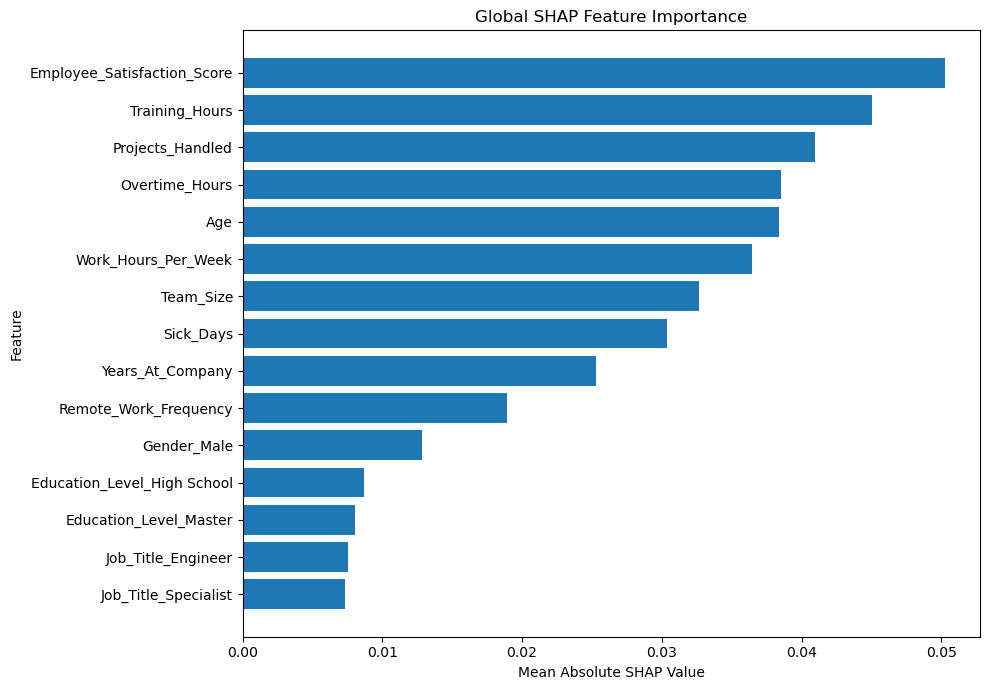

In [15]:
# Plot the 15 most influential features by mean absolute SHAP value

top_features = importance_df.head(15).sort_values(
    by="Mean_SHAP",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

### Interpretation of the Global SHAP Visualisation

The global SHAP visualisation confirms that predictive attribution is distributed across several features rather than being concentrated in a single dominant predictor. `Employee_Satisfaction_Score` has the largest mean absolute SHAP value, followed by `Training_Hours`, `Projects_Handled`, `Overtime_Hours` and `Age`.

The remaining features show progressively smaller attribution magnitudes, indicating that the fitted XGBoost model uses information from multiple organisational, behavioural and demographic characteristics when generating its classifications. This distributed pattern contrasts with the pre-refinement diagnostic analysis, in which `Monthly_Salary` provided exceptionally strong information about the target.

However, the relative importance displayed in the figure should be interpreted in the context of the model's modest predictive performance. A larger mean absolute SHAP value indicates that a feature contributes more strongly to the predictions of this fitted model; it does not demonstrate that the feature is a strong predictor in absolute terms, causes employee performance, or represents an appropriate target for organisational intervention.

The visualisation therefore provides transparency regarding how the full-data refitted XGBoost model distributes predictive attribution across the retained feature set, rather than evidence of causal relationships or independent predictor validity.

## 1.6 Class-Specific SHAP Analysis

The global SHAP analysis averages feature-attribution magnitude across all five employee-performance classes. Although this provides an overall view of model behaviour, it may conceal differences in how the fitted XGBoost classifier uses predictors when distinguishing between individual `Performance_Score` categories.

Class-specific SHAP importance is therefore examined separately for each of the five performance classes. For each class, the mean absolute SHAP value is calculated across all observations for every encoded predictor. This enables comparison of the relative feature-attribution patterns associated with Performance Scores 1–5.

As with the global analysis, these class-specific values describe the behaviour of the fitted XGBoost model rather than causal relationships or independently validated determinants of employee performance.

In [16]:
# Calculate class-specific mean absolute SHAP importance

class_importance = {}

for class_idx in range(shap_values.shape[2]):

    mean_abs_shap = np.abs(
        shap_values[:, :, class_idx]
    ).mean(axis=0)

    class_importance[
        f"Performance Score {class_idx + 1}"
    ] = mean_abs_shap

class_importance_df = pd.DataFrame(
    class_importance,
    index=X_encoded.columns
)

class_importance_df.head()

,Performance Score 1,Performance Score 2,Performance Score 3,Performance Score 4,Performance Score 5
Age,0.037364,0.039941,0.039279,0.038828,0.036686
Years_At_Company,0.028592,0.028009,0.020255,0.024219,0.025355
Work_Hours_Per_Week,0.037367,0.030874,0.035422,0.039042,0.039681
Projects_Handled,0.039024,0.042819,0.039157,0.042100,0.041741
Overtime_Hours,0.038019,0.044319,0.034707,0.040993,0.034574


In [17]:
# Display the five most influential features for each performance class

top_features_by_class = {}

for class_name in class_importance_df.columns:

    top_features_by_class[class_name] = (
        class_importance_df[class_name]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

top_features_by_class_df = pd.DataFrame(
    top_features_by_class,
    index=[
        "1st",
        "2nd",
        "3rd",
        "4th",
        "5th"
    ]
)

top_features_by_class_df

,Performance Score 1,Performance Score 2,Performance Score 3,Performance Score 4,Performance Score 5
1st,Employee_Satisfaction_Score,Employee_Satisfaction_Score,Employee_Satisfaction_Score,Training_Hours,Employee_Satisfaction_Score
2nd,Training_Hours,Overtime_Hours,Training_Hours,Employee_Satisfaction_Score,Training_Hours
3rd,Projects_Handled,Training_Hours,Age,Projects_Handled,Projects_Handled
4th,Overtime_Hours,Projects_Handled,Projects_Handled,Overtime_Hours,Work_Hours_Per_Week
5th,Work_Hours_Per_Week,Age,Team_Size,Work_Hours_Per_Week,Age


### Interpretation of Class-Specific SHAP Importance

The class-specific SHAP analysis demonstrates both consistency and variation in how the fitted XGBoost model uses the retained predictors across the five employee-performance categories.

`Employee_Satisfaction_Score` is the highest-ranked feature for Performance Scores 1, 2, 3 and 5, while `Training_Hours` is the highest-ranked feature for Performance Score 4. Both variables appear prominently across multiple classes, indicating that they make comparatively large contributions to the model's classifications across much of the target structure.

`Projects_Handled` also appears among the five highest-ranked features for every performance category, although its relative position varies between classes. Other predictors show greater class-specific variation. `Overtime_Hours` is prominent for Performance Scores 1, 2 and 4, `Age` appears among the five highest-ranked features for Scores 2, 3 and 5, and `Work_Hours_Per_Week` appears for Scores 1, 4 and 5. `Team_Size` enters the five highest-ranked features specifically for Performance Score 3.

These differences indicate that the fitted XGBoost model does not use the retained predictors identically across all five target categories. Nevertheless, the recurrence of several features across classes suggests that the model's attribution structure is concentrated around a relatively consistent group of organisational, behavioural and demographic characteristics rather than entirely different feature sets for each performance category.

The class-specific rankings should not be interpreted as evidence that these characteristics determine membership of particular employee-performance categories. They describe the relative attribution patterns within the fitted XGBoost classifier. Given the modest predictive performance established in Notebook 3, these patterns provide insight into model behaviour rather than evidence of strong or causal relationships with employee performance.

## Class-Specific SHAP Importance Visualisation

To compare feature-attribution patterns across the five employee-performance categories, class-specific mean absolute SHAP values are visualised using a heatmap.

The heatmap enables both the magnitude and distribution of model attribution to be compared across performance classes. Higher values indicate that a feature makes a larger average contribution to the fitted model's output for the corresponding class.

As with the preceding analyses, the visualisation represents model-specific attribution rather than causal importance.

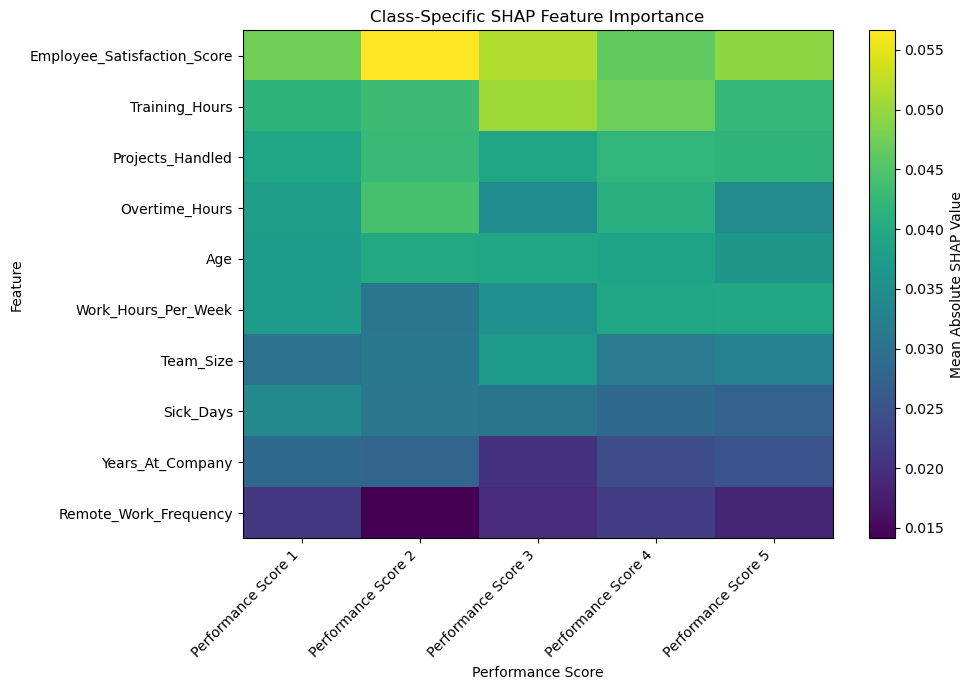

In [18]:
# Select the ten most important features globally
top_10_features = (
    importance_df
    .head(10)["Feature"]
    .tolist()
)

# Extract class-specific SHAP importance
heatmap_data = class_importance_df.loc[top_10_features]

plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.colorbar(
    label="Mean Absolute SHAP Value"
)

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Performance Score")
plt.ylabel("Feature")
plt.title("Class-Specific SHAP Feature Importance")

plt.tight_layout()
plt.show()

### Interpretation of Class-Specific SHAP Visualisation

The class-specific SHAP heatmap demonstrates that the fitted XGBoost model uses a broadly similar group of predictors across the five employee-performance categories, while the magnitude of their contributions varies between classes.

`Employee_Satisfaction_Score` shows comparatively high attribution across all five classes and is particularly prominent for Performance Score 2. `Training_Hours` also contributes strongly across the target categories, with its largest attribution evident for Performance Score 3. `Projects_Handled` displays a comparatively consistent attribution pattern across classes, indicating that it contributes to the model's classification behaviour without being concentrated strongly within a single performance category.

Other features demonstrate greater variation between classes. For example, the attribution associated with `Overtime_Hours`, `Age`, `Work_Hours_Per_Week` and `Team_Size` changes across the five performance categories. In contrast, `Remote_Work_Frequency` consistently exhibits relatively low mean absolute SHAP values within the ten globally highest-ranked features.

Overall, the heatmap indicates that the model does not rely on entirely different predictor sets for different performance categories. Instead, a relatively consistent group of features contributes across classes, with differences primarily occurring in the magnitude of attribution.

These class-specific patterns should be interpreted as characteristics of the fitted XGBoost model rather than evidence that particular employee characteristics determine specific performance categories. Given the modest predictive performance established in Notebook 3, the heatmap improves transparency regarding model behaviour but does not establish predictive validity, causality or substantive organisational importance.

## Local SHAP Explanation

Global and class-specific SHAP analyses describe model behaviour across groups of observations but do not demonstrate how feature contributions combine within an individual prediction. A local explanation is therefore examined for a reproducibly selected observation from the dataset.

The purpose of this analysis is illustrative rather than evaluative. The selected observation is used to demonstrate how SHAP decomposes an individual XGBoost prediction into feature-level contributions relative to the model's expected output.

Because the classifier's overall predictive performance is modest, the local explanation should not be interpreted as a reliable assessment of an individual employee or as evidence supporting employee-level decision-making.

In [19]:
# Select an observation reproducibly
observation_idx = 0

# Generate predicted probabilities
predicted_probabilities = xgb_model.predict_proba(
    X_encoded.iloc[[observation_idx]]
)[0]

predicted_class_idx = np.argmax(predicted_probabilities)
predicted_score = predicted_class_idx + 1

actual_score = int(y.iloc[observation_idx])

print("Observation:", observation_idx)
print("Actual Performance Score:", actual_score)
print("Predicted Performance Score:", predicted_score)
print(
    "Predicted Probability:",
    round(predicted_probabilities[predicted_class_idx], 4)
)

Observation: 0
Actual Performance Score: 5
Predicted Performance Score: 5
Predicted Probability: 0.2513


In [20]:
# Extract SHAP values for the predicted class

local_shap_values = shap_values[
    observation_idx,
    :,
    predicted_class_idx
]

local_explanation = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Feature_Value": X_encoded.iloc[observation_idx].values,
    "SHAP_Value": local_shap_values
})

local_explanation["Absolute_SHAP"] = np.abs(
    local_explanation["SHAP_Value"]
)

local_explanation = local_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
)

local_explanation.head(10)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,Age,55.00,0.071495,0.071495
5,Sick_Days,2.00,0.058368,0.058368
7,Team_Size,14.00,0.057002,0.057002
2,Work_Hours_Per_Week,33.00,0.056689,0.056689
3,Projects_Handled,32.00,-0.052291,0.052291
6,Remote_Work_Frequency,0.00,0.036027,0.036027
13,Department_IT,1.00,0.031590,0.031590
1,Years_At_Company,2.00,-0.029260,0.029260
9,Employee_Satisfaction_Score,2.63,0.024928,0.024928
26,Education_Level_High School,1.00,0.023729,0.023729


Local SHAP explanation for predicted Performance Score 5


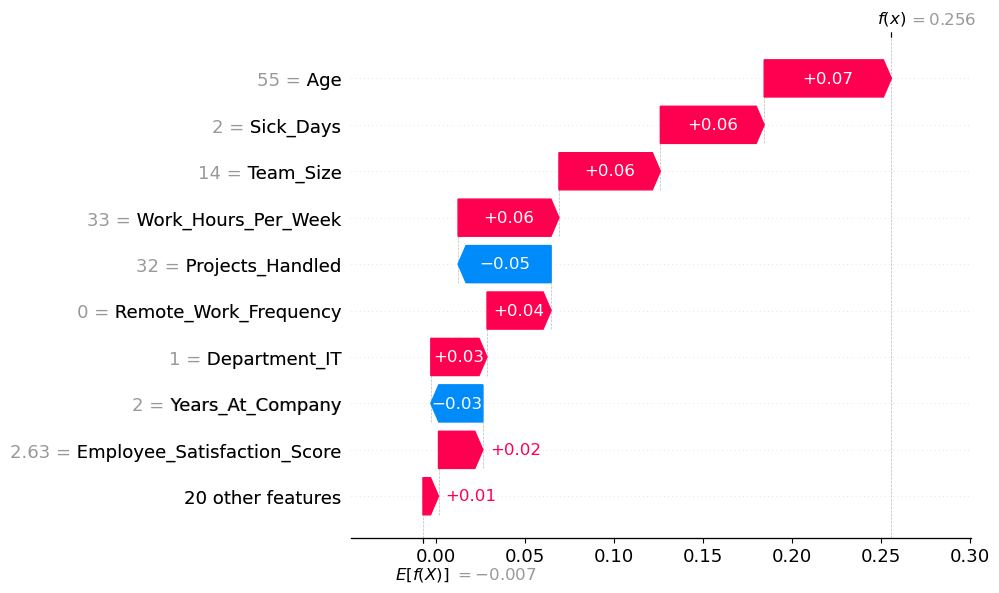

In [22]:
# Create a SHAP explanation for the predicted class

local_shap_explanation = shap.Explanation(
    values=shap_values[
        observation_idx,
        :,
        predicted_class_idx
    ],
    base_values=explainer.expected_value[predicted_class_idx],
    data=X_encoded.iloc[observation_idx].values,
    feature_names=X_encoded.columns
)

print(
    f"Local SHAP explanation for predicted Performance Score "
    f"{predicted_score}"
)

shap.plots.waterfall(
    local_shap_explanation,
    max_display=10
)

### Interpretation of the Local SHAP Explanation

The local SHAP analysis illustrates how individual feature values contributed to the fitted XGBoost model's output for a single reproducibly selected observation (Observation 0). The employee's actual `Performance_Score` was **5**, and the model also predicted **Performance Score 5**, with a predicted probability of **25.13%**.

Although the predicted class was correct for this observation, the probability of 25.13% indicates considerable uncertainty across the five possible performance categories. The local explanation should therefore be interpreted as an illustration of model behaviour rather than evidence of a confident or reliable employee-level prediction.

For the model output associated with Performance Score 5, `Age` (55) produced the largest positive SHAP contribution (+0.0715). `Sick_Days` (2), `Team_Size` (14) and `Work_Hours_Per_Week` (33) also made comparatively large positive contributions. Additional positive contributions were associated with `Remote_Work_Frequency` (0), membership of `Department_IT`, and `Employee_Satisfaction_Score` (2.63).

In contrast, `Projects_Handled` (32) produced the largest negative contribution among the displayed features (-0.0523), while `Years_At_Company` (2) also contributed negatively (-0.0293). These positive and negative contributions combine with the model's expected output to produce the final model output displayed in the waterfall plot for Performance Score 5.

Importantly, the direction of these SHAP contributions is specific to this observation, this predicted class and this fitted model. For example, the positive contribution associated with `Age = 55` should not be interpreted as evidence that greater age increases employee performance. Similarly, the negative contribution associated with `Projects_Handled = 32` does not establish that handling more projects reduces performance.

The local explanation therefore demonstrates the principal value of SHAP in this study: it makes an otherwise complex model prediction more transparent by identifying the features that contributed positively or negatively to an individual model output. However, given the model's modest overall predictive performance, such explanations would not provide a sufficient basis for automated employee-performance decisions.

## Conclusion

This notebook applied SHAP to improve the transparency of the full-data refitted XGBoost classifier. Global analysis showed that predictive attribution was distributed across multiple features, led by `Employee_Satisfaction_Score`, `Training_Hours` and `Projects_Handled`, rather than being dominated by a single predictor. Class-specific analysis further demonstrated that the relative contribution of these features varied across the five `Performance_Score` categories.

The local SHAP analysis illustrated how individual feature values contributed positively and negatively to a specific model output, demonstrating the value of explainability for understanding individual predictions.

However, these findings must be interpreted alongside the modest predictive performance established in Notebook 3. SHAP explains the behaviour of the fitted model; it does not establish causal relationships, independently validate the identified features as determinants of employee performance, or demonstrate suitability for automated employee-level decision-making.

Overall, the explainability analysis improves understanding of how the XGBoost model uses the refined predictor set while reinforcing the importance of interpreting machine-learning explanations within the context of model performance, predictor validity and responsible organisational use.